# MNIST/CIFAR10 with 10-class output
Each output node is treated as a separate ReLU network

In [5]:
import numpy as np
import tqdm, utils, theory, pickle, cluster_utils, data, sys, torch
import matplotlib.pyplot as plt

ON_CLUSTER, data_path, output_home_path = cluster_utils.initialize()
parser = cluster_utils.Args()
parser.add('P', 1000)  # size of each training set
parser.add('P_test', 1000)  # size of each testing set
parser.add('n_tasks', 10, help='number of tasks in the sequence')
parser.add('T', 0.0, help='temperature')
parser.add('sigma', 0.2, help='weight variance')
parser.add('depth', 3, help='num of hidden layers. setting depth=0 would use the input kernel')
parser.add('seed', 1, help='random seed')
parser.add('fixed_w', 0, help='whether or not to fix weights. ignored for linear networks')
parser.add('lambda_val', 1e3, help='lambda')
parser.add('dataset', 'mnist', help='dataset to use: mnist/cifar/fashion')
parser.add('permutation', 1.0, help='strength of permutation. 1.0=full permutation')
parser.add('n_epochs', 1, help='number of times to go through the sequence of tasks')
parser.add('resample', 1, help='whether to sample new data points for each task')
parser.add('interpolate', 0, help='if True, linearly interpolate between two permutation matrices')
args = parser.parse_args()

args.P = np.min([args.P, int(50000 / args.n_tasks)])
args.P_test = np.min([args.P, int(10000 / args.n_tasks)])

run_name = f'{args.BATCH_NAME}_{args.TRIAL_IND}'

logger = cluster_utils.Logger(output_path=f'{output_home_path}{args.BATCH_NAME}/',
                              run_name=run_name, only_print=not ON_CLUSTER)
logger.log(str(args))
results = {'args': args}

torch.manual_seed(args.seed)
print(data_path)
seq_of_train_x, seq_of_test_x, seq_of_train_y_digit, seq_of_test_y_digit = \
    data.prepare_sequential_dataset(args.n_tasks, args.P, args.P_test, dataset_name=args.dataset,
                                    resample=bool(args.resample),
                                    permutation=args.permutation, data_path=data_path, n_epochs=args.n_epochs,
                                    interpolate=bool(args.interpolate))

single_seed_train_accuracy, single_seed_test_accuracy, single_seed_train_loss, single_seed_test_loss = \
    data.get_multihead_accuracy(seq_of_train_x=seq_of_train_x, seq_of_test_x=seq_of_test_x,
                                seq_of_train_y_digit=seq_of_train_y_digit, seq_of_test_y_digit=seq_of_test_y_digit,
                                sigma=args.sigma, lamb=args.lambda_val,
                                fixed_w=bool(args.fixed_w), depth=args.depth,
                                write_fn=logger.log)
#
# results['test acc'] = single_seed_test_accuracy
# results['train acc'] = single_seed_train_accuracy
# results['train loss'] = single_seed_train_loss
# results['test loss'] = single_seed_test_loss


# training_variances, test_variances, =\
#     theory.compute_predictor_variances(seq_of_train_x=seq_of_train_x,
#                                        w_var=args.sigma**2, P_test=args.P_test,
#                                        lambda_val=args.lambda_val,
#                                        seq_of_test_x=seq_of_test_x,
#                                        fix_weights=args.fixed_w, depth=args.depth)
# mean_training_variances = np.zeros((len(seq_of_train_x), len(seq_of_train_x)))
# for i in range(len(seq_of_train_x)):
#     for j in range(len(seq_of_train_x)):
#         mean_training_variances[i, j] = np.mean(np.diag(training_variances[i, j]))
#
# mean_test_variances = np.zeros((test_variances.shape[0], test_variances.shape[1]))
# for i in range(test_variances.shape[0]):
#     for j in range(test_variances.shape[1]):
#         mean_test_variances[i, j] = np.mean(np.diag(test_variances[i, j]))
#
# results['test var'] = mean_test_variances
# results['train var'] = mean_training_variances

logger.log('starting to compute batch accuracy')
# test accuracy using all the training data in one batch
batch_acc = torch.zeros(args.n_tasks)
batch_loss = torch.zeros(args.n_tasks)
for task_ind in tqdm.trange(args.n_tasks):
    merged_train_x = torch.flip(seq_of_train_x, dims=[0])[:task_ind+1].reshape(-1, seq_of_train_x.shape[-1])
    merged_train_y = torch.flip(seq_of_train_y_digit, dims=[0])[:task_ind+1].flatten()
    merged_test_x = seq_of_test_x[-1]
    merged_test_y = seq_of_test_y_digit[-1]

    batch_acc[task_ind], batch_loss[task_ind] =\
        theory.multihead_one_task_accuracy(train_x=merged_train_x, train_y=merged_train_y,
                                           test_x=merged_test_x, test_y=merged_test_y,
                                           depth=args.depth)

logger.log('finished computing batch accuracy')

if ON_CLUSTER:

    logger.finish(results)
    sys.exit()

/Users/haozheshan/Dropbox/codes/gp_continual_learning/data.py:204: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y = torch.tensor(dataset.targets).float()
/Users/haozheshan/Dropbox/codes/gp_continual_learning/data.py:22: UserWarning: get_multihead_accuracy assumes that there are 10 classes.
  warnings.warn('get_multihead_accuracy assumes that there are 10 classes.')


07/12/2022 14:10:18 | Name of this run: BATCH_NAME_0
07/12/2022 14:10:18 | Namespace(f=None, cluster=0, BATCH_NAME='BATCH_NAME', TRIAL_IND=0, P=1000, P_test=1000, n_tasks=10, T=0.0, sigma=0.2, depth=3, seed=1, fixed_w=0, lambda_val=1000.0, dataset='mnist', permutation=1.0, n_epochs=1, resample=1, interpolate=0)
None


  0%|          | 0/10 [00:00<?, ?it/s]

07/12/2022 14:10:18 | starting head 0


/Users/haozheshan/Dropbox/codes/gp_continual_learning/theory.py:375: UserWarning: arccosine kernel computation is assuming that all inputs have the same norm.
  warnings.warn('arccosine kernel computation is assuming that all inputs have the same norm.')
 10%|█         | 1/10 [00:51<07:45, 51.71s/it]

...

07/12/2022 14:18:36 | starting head 9


100%|██████████| 10/10 [09:13<00:00, 55.33s/it]


07/12/2022 14:19:31 | starting to compute batch accuracy


100%|██████████| 10/10 [00:17<00:00,  1.77s/it]

07/12/2022 14:19:49 | finished computing batch accuracy


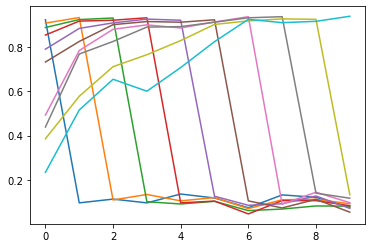

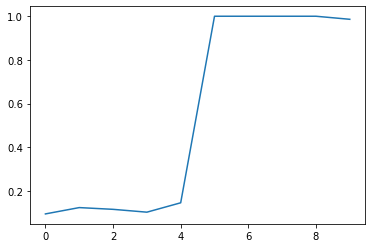

In [10]:
plt.figure()
plt.plot(single_seed_test_accuracy)

plt.figure()
plt.plot(single_seed_train_accuracy[5])

In [72]:
for i in range(args.n_tasks):
            seq_of_train_x[i] = seq_of_train_x[i][torch.argsort(seq_of_train_y_digit[i])]

k12 = theory.arccos_kernel_deep(seq_of_train_x[0], seq_of_train_x[1], depth=1, var1=1)
k1 = theory.arccos_kernel_deep(seq_of_train_x[0], seq_of_train_x[0], depth=1, var1=1)
k2 = theory.arccos_kernel_deep(seq_of_train_x[1], seq_of_train_x[1], depth=1, var1=1)

lambda0s = np.linspace(0, 1, 50)

plt.figure()
for _lamb0 in lambda0s:
    mat = k12 @ theory.inverse(k2) @ (torch.eye(args.P) - _lamb0 * k12.T @ theory.inverse(k1)) + torch.eye(args.P) * (_lamb0 - 1)
    plt.scatter(_lamb0, torch.trace(mat.T @ mat / args.P))
plt.show()

tensor(0.8526)

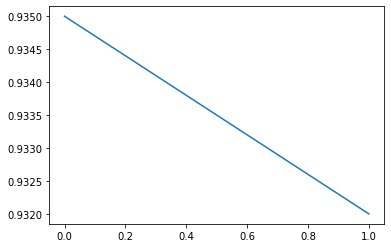

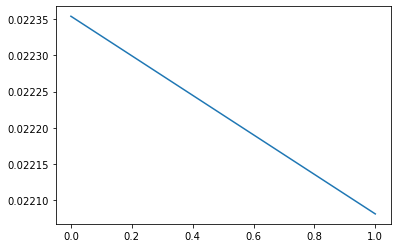

In [16]:
plt.figure()
plt.plot(batch_acc)

plt.figure()
plt.plot(batch_loss)

In [49]:
def tabulate_forgetting(forgetting_matrix, title):
    print(title)
    matrix_for_printing = np.hstack([(np.arange(len(forgetting_matrix)) + 1).reshape(-1, 1), forgetting_matrix.T])
    print(tabulate(matrix_for_printing, headers=['# tasks learnt'] + [f'task{i+1}' for i in range(len(forgetting_matrix))]))

print(f'Permuted MNIST: P={P},P_test={P_test},sigma={sigma},seed:{SEED},lambda={lambda_val},depth={depth}')
tabulate_forgetting(single_seed_train_accuracy, 'training accuracy')
tabulate_forgetting(single_seed_test_accuracy, 'test accuracy')

Permuted MNIST: P=500,P_test=100,sigma=0.2,seed:1,lambda=10000000,depth=1
training accuracy
  # tasks learnt    task1    task2    task3    task4    task5    task6    task7    task8    task9    task10
----------------  -------  -------  -------  -------  -------  -------  -------  -------  -------  --------
               1    1        0.372    0.372    0.28     0.424    0.352    0.352    0.348    0.288     0.248
               2    0.874    1        0.444    0.442    0.514    0.35     0.36     0.304    0.442     0.252
               3    0.818    0.768    1        0.36     0.302    0.292    0.286    0.482    0.358     0.438
               4    0.678    0.756    0.9      1        0.34     0.36     0.422    0.39     0.486     0.434
               5    0.674    0.772    0.758    0.818    1        0.47     0.478    0.464    0.462     0.374
               6    0.628    0.762    0.724    0.688    0.906    1        0.354    0.528    0.53      0.496
               7    0.646    0.822    0.7   

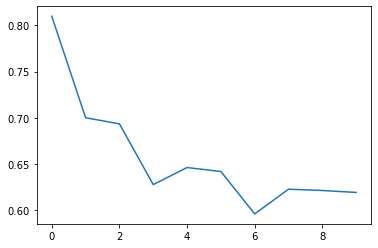

In [50]:
plt.figure()
avg_test_acc_over_tasks = np.zeros(n_tasks)
for i in range(n_tasks):
    avg_test_acc_over_tasks[i] = torch.mean(single_seed_test_accuracy[:i+1, i])
plt.plot(avg_test_acc_over_tasks)

In [27]:
avg_test_variance = np.zeros((n_tasks, n_tasks))  # averaged over data points
for i in range(n_tasks):
    for j in range(n_tasks):
        avg_test_variance[i, j] = np.mean(np.diag(test_variances[i, j]))

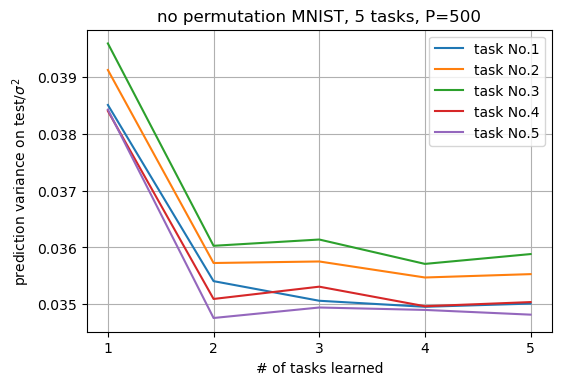

In [28]:


plt.figure(dpi=100)
for task_ind in range(n_tasks):
    plt.plot(np.arange(n_tasks) + 1, avg_test_variance[task_ind] / sigma**2, label=f'task No.{task_ind+1}')
plt.ylabel('prediction variance on test/$\sigma^2$')
plt.title('no permutation MNIST, 5 tasks, P=500')
plt.xlabel('# of tasks learned')
_ = plt.xticks(np.arange(n_tasks) + 1)
plt.legend()
plt.grid()

NameError: name 'torch' is not defined